# Baseline-модель для прогнозирования медицинских расходов

Этот ноутбук представляет собой быстрый baseline для задачи прогнозирования годовых медицинских расходов пациента. Его основная цель — получить первое рабочее решение, проверить, что данные корректно загружаются и обрабатываются, а также зафиксировать стартовый уровень качества модели.

Важно учитывать ограничения этого подхода:

- проводится только базовая разведочная аналитика без глубокого анализа зависимостей и выбросов;
- используется простой train/test split без кросс-валидации;
- модель Random Forest обучается практически «из коробки», без подбора гиперпараметров;
- не сравниваются разные алгоритмы и разные варианты предобработки признаков;
- качество оценивается только на одной тестовой выборке, поэтому результат может зависеть от конкретного разбиения данных;
- интерпретация модели ограничена и не является полноценным анализом влияния факторов.

Это отправная точка для дальнейшего улучшения: более аккуратного EDA, настройки пайплайнов, кросс-валидации, подбора гиперпараметров и сравнения нескольких моделей, включая ансамбли.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

import shap
import phik
from phik import resources, report

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/medical_cost_prediction_dataset.csv")
df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


In [3]:
df.shape

(5000, 20)

In [4]:
df.columns

Index(['age', 'gender', 'bmi', 'smoker', 'diabetes', 'hypertension',
       'heart_disease', 'asthma', 'physical_activity_level', 'daily_steps',
       'sleep_hours', 'stress_level', 'doctor_visits_per_year',
       'hospital_admissions', 'medication_count', 'insurance_type',
       'insurance_coverage_pct', 'city_type', 'previous_year_cost',
       'annual_medical_cost'],
      dtype='object')

## Корректировка таргета

Зачем делаем корректировку таргета?

- Изначально annual_medical_cost — это чистые расходы пациента с учётом того, что страховая покрыла insurance_coverage_pct % стоимости. 

- Но для моделирования реального сценария страховщика мы должны получать оценку **полной** стоимости медицинских расходов пациента, чтобы подобрать для него страховку. Поэтому мы восстанавливаем полную стоимость по формуле.

- По этой же причине insurance_type и insurance_coverage_pct исключаются из предикторов, т.к. в реальном сценарии мы предполагаем, что у пациента пока нет никакой страховки.

In [5]:
df["insurance_coverage_pct"] = df["insurance_coverage_pct"].astype(float)

In [6]:
df["annual_medical_cost"] = round(df["annual_medical_cost"] / (1 - df["insurance_coverage_pct"]/100))

In [7]:
df.drop(columns=["insurance_type", "insurance_coverage_pct"], axis=1, inplace=True)

## Общее описание датасета

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14  medication_count        

In [9]:
df.describe()

,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,previous_year_cost,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.299000,25.970820,0.207600,0.288000,0.14220,0.096400,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,10248.515400,19123.380600
std,20.646851,5.046651,0.405629,0.452876,0.34929,0.295169,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,5626.095015,6995.684871
min,18.000000,6.400000,0.000000,0.000000,0.00000,0.000000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,500.000000,3594.000000
25%,36.000000,22.600000,0.000000,0.000000,0.00000,0.000000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,5342.750000,13934.000000
50%,53.000000,25.900000,0.000000,0.000000,0.00000,0.000000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,10281.000000,18538.000000
75%,71.000000,29.400000,0.000000,1.000000,0.00000,0.000000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,15034.500000,23387.250000
max,89.000000,43.600000,1.000000,1.000000,1.00000,1.000000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,19996.000000,51016.000000


In [10]:
df.isnull().sum()

age                        0
gender                     0
bmi                        0
smoker                     0
diabetes                   0
hypertension               0
heart_disease              0
asthma                     0
physical_activity_level    0
daily_steps                0
sleep_hours                0
stress_level               0
doctor_visits_per_year     0
hospital_admissions        0
medication_count           0
city_type                  0
previous_year_cost         0
annual_medical_cost        0
dtype: int64

In [11]:
df.duplicated().sum()

0

## EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

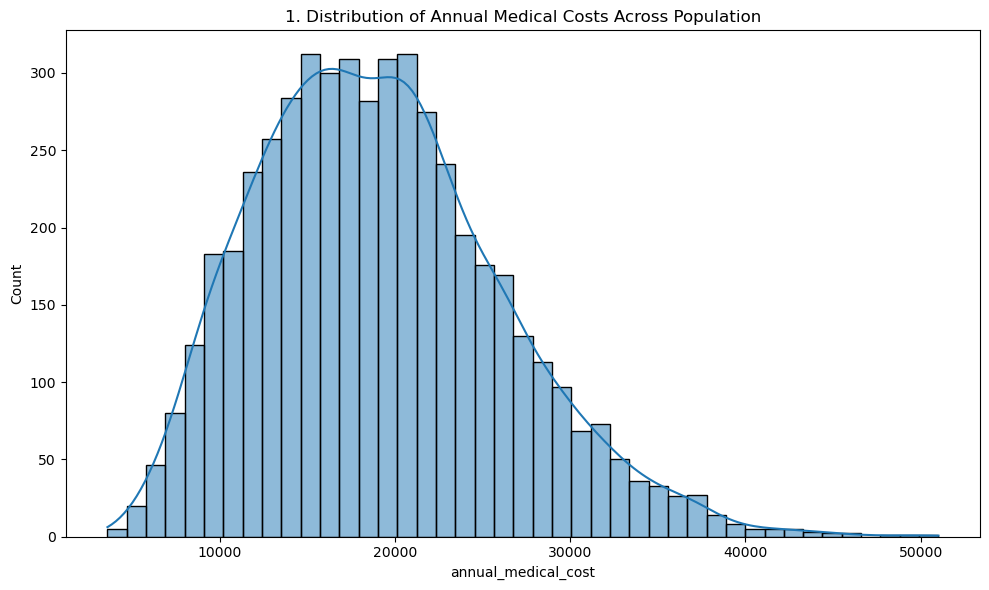

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['annual_medical_cost'], kde=True)
plt.title(f'{plot_no}. Distribution of Annual Medical Costs Across Population')
show_fig()
plot_no += 1

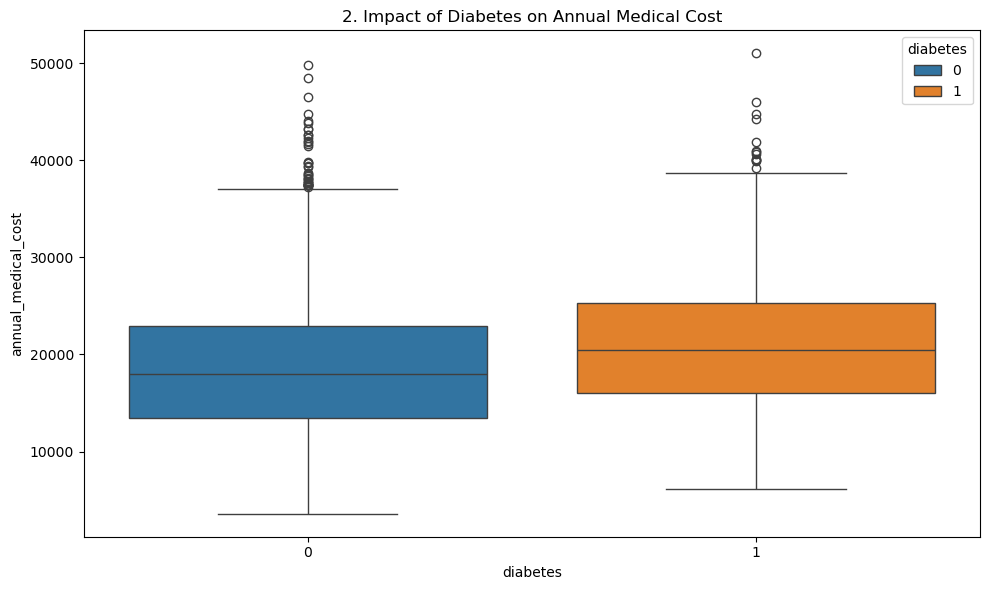

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes', y='annual_medical_cost', hue='diabetes', data=df)
plt.title(f'{plot_no}. Impact of Diabetes on Annual Medical Cost')
show_fig()
plot_no += 1

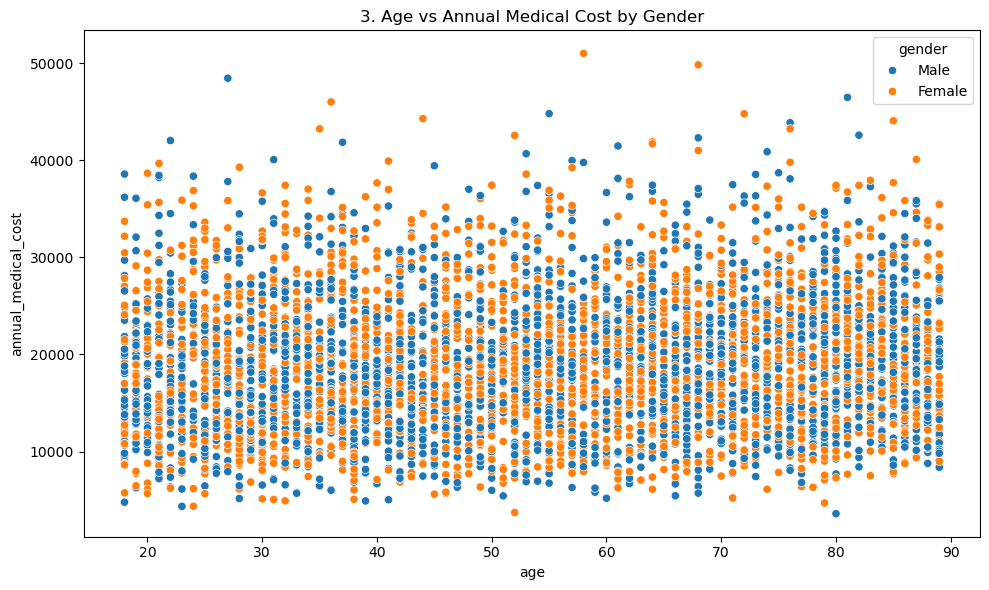

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='annual_medical_cost', hue='gender', data=df)
plt.title(f'{plot_no}. Age vs Annual Medical Cost by Gender')
show_fig()
plot_no += 1

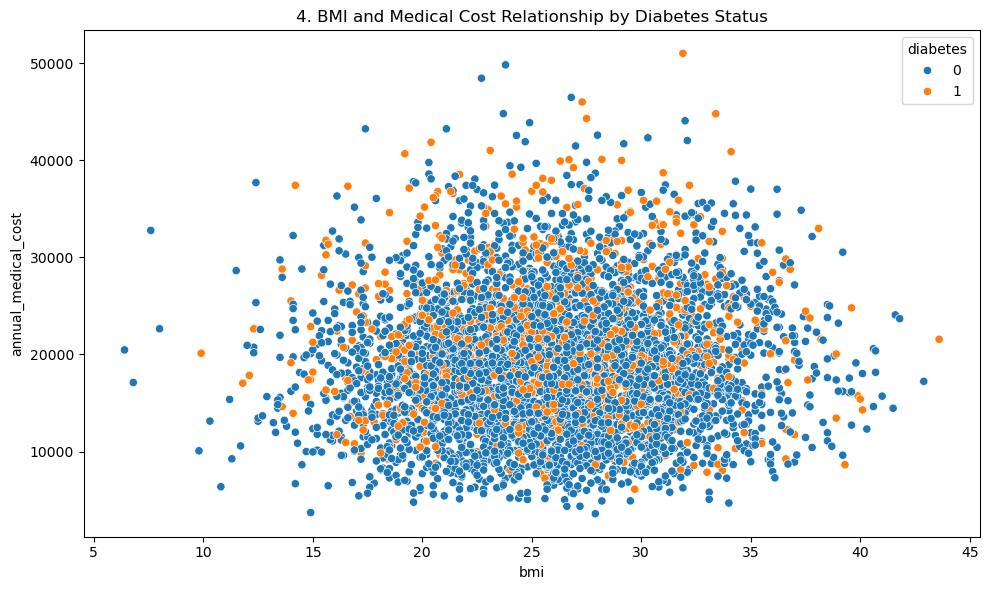

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y='annual_medical_cost', hue='diabetes', data=df)
plt.title(f'{plot_no}. BMI and Medical Cost Relationship by Diabetes Status')
show_fig()
plot_no += 1

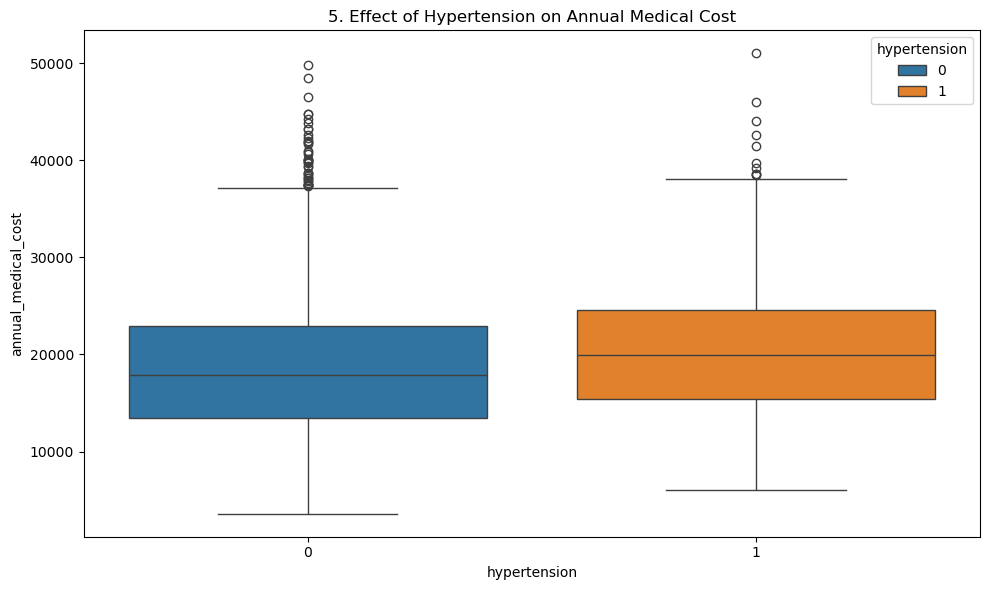

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='hypertension', y='annual_medical_cost', hue='hypertension', data=df)
plt.title(f'{plot_no}. Effect of Hypertension on Annual Medical Cost')
show_fig()
plot_no += 1

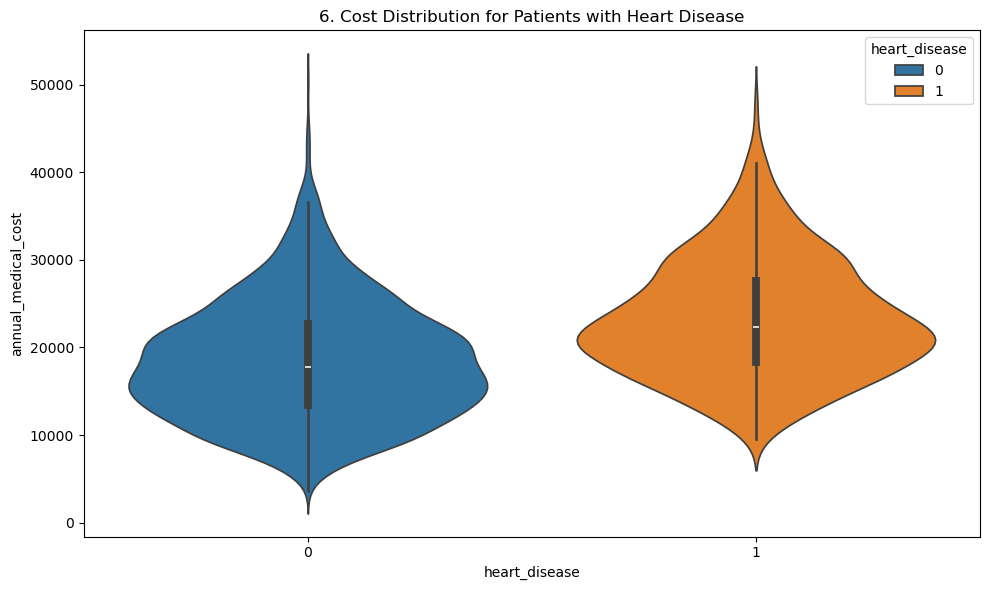

In [18]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='heart_disease', y='annual_medical_cost', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Cost Distribution for Patients with Heart Disease')
show_fig()
plot_no += 1

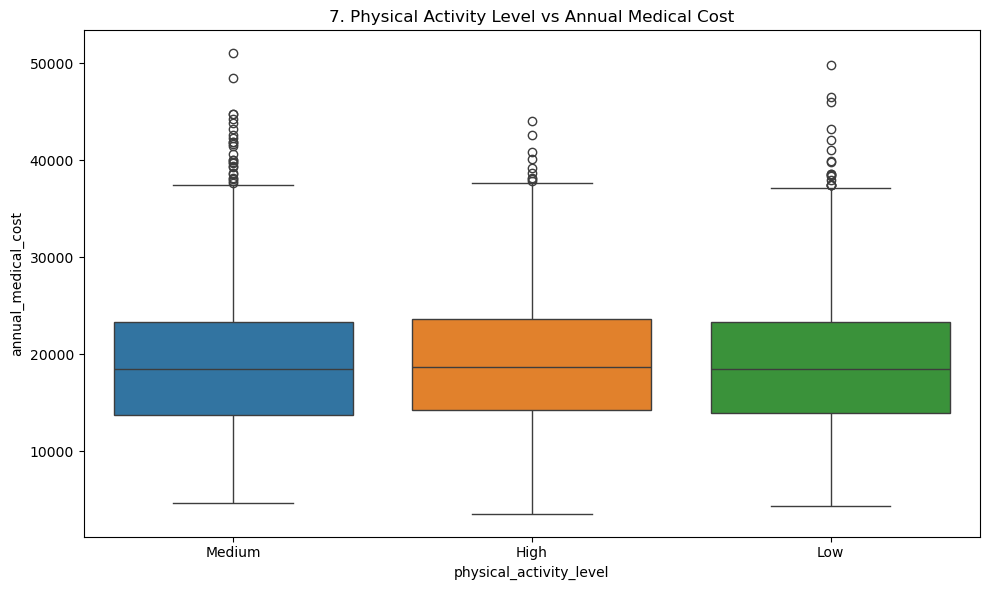

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='physical_activity_level', y='annual_medical_cost', hue='physical_activity_level', data=df)
plt.title(f'{plot_no}. Physical Activity Level vs Annual Medical Cost')
show_fig()
plot_no += 1

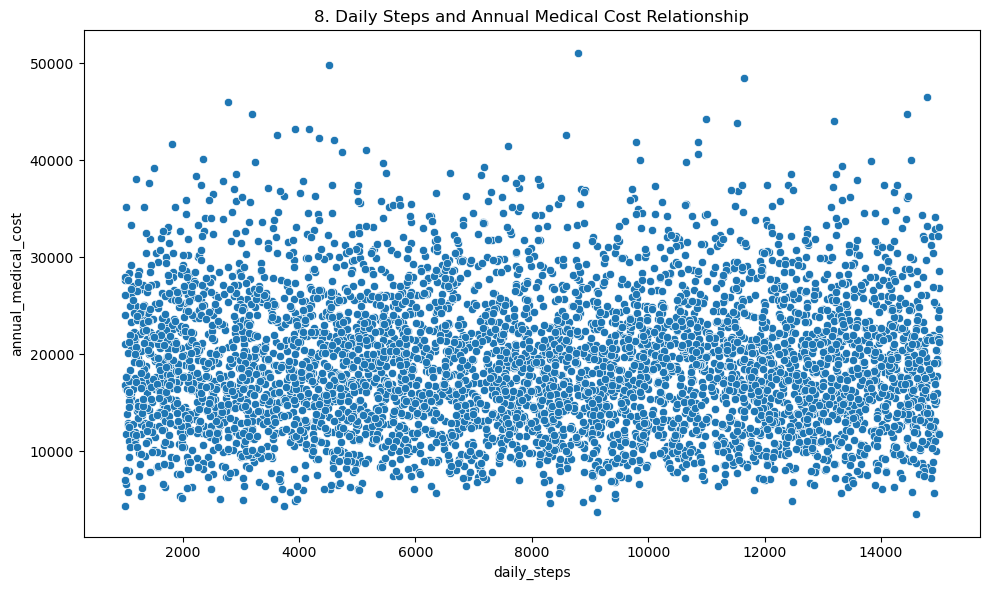

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_steps', y='annual_medical_cost', data=df)
plt.title(f'{plot_no}. Daily Steps and Annual Medical Cost Relationship')
show_fig()
plot_no += 1

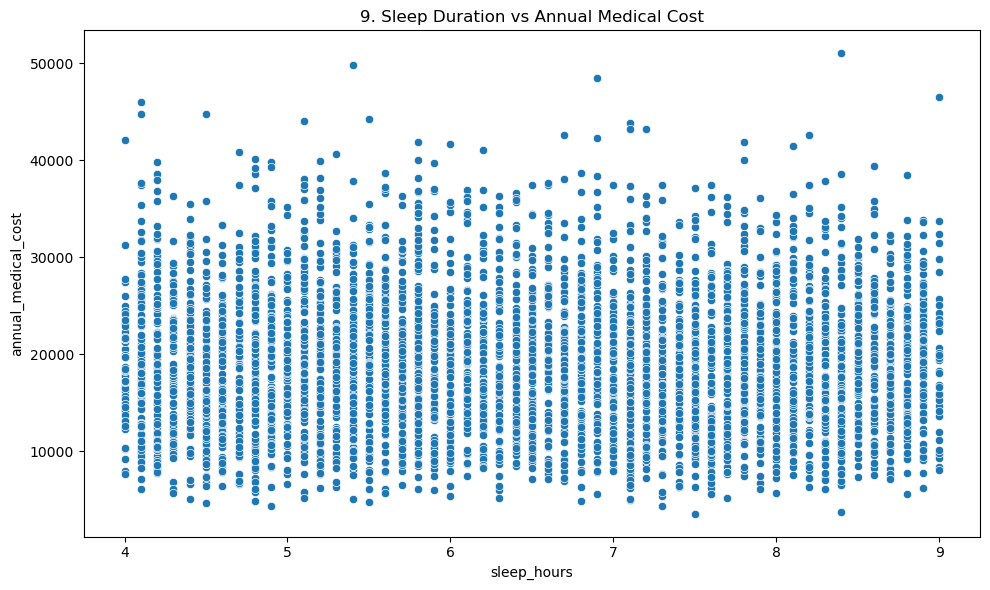

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='sleep_hours', y='annual_medical_cost', data=df)
plt.title(f'{plot_no}. Sleep Duration vs Annual Medical Cost')
show_fig()
plot_no += 1

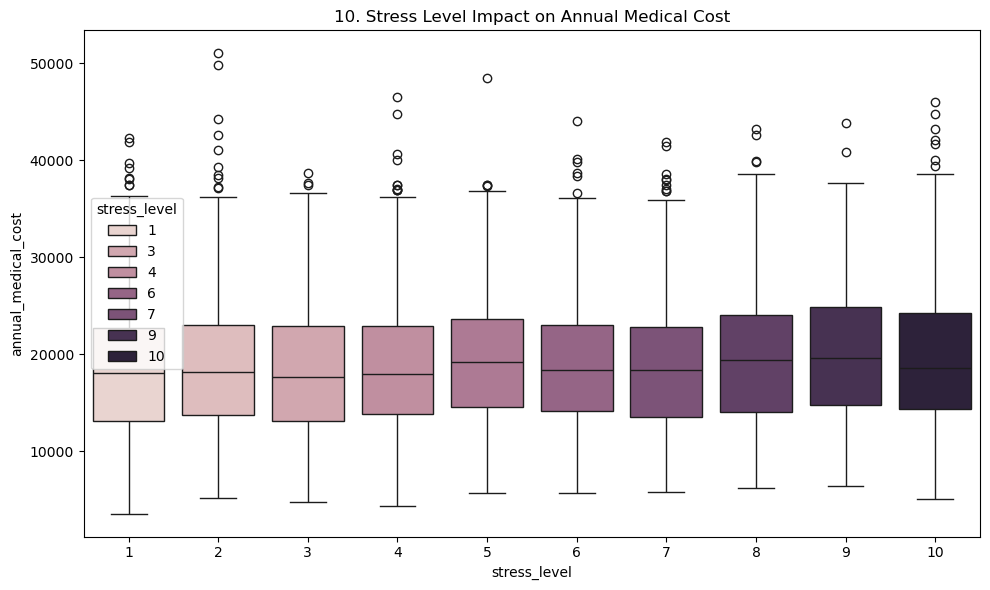

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='stress_level', y='annual_medical_cost', hue='stress_level', data=df)
plt.title(f'{plot_no}. Stress Level Impact on Annual Medical Cost')
show_fig()
plot_no += 1

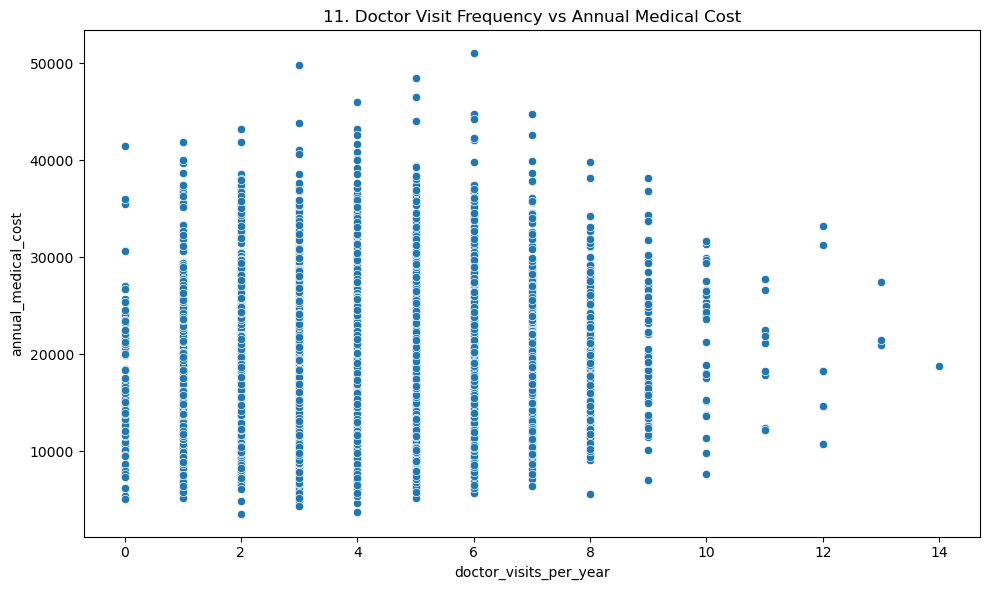

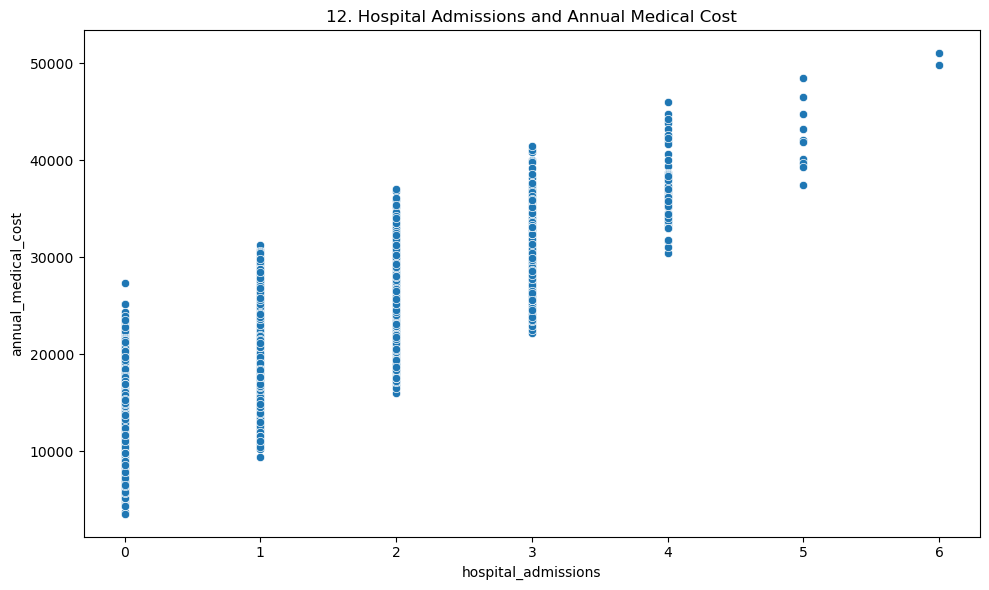

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='doctor_visits_per_year', y='annual_medical_cost', data=df)
plt.title(f'{plot_no}. Doctor Visit Frequency vs Annual Medical Cost')
show_fig()
plot_no += 1
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='hospital_admissions', y='annual_medical_cost', data=df)
plt.title(f'{plot_no}. Hospital Admissions and Annual Medical Cost')
show_fig()
plot_no += 1

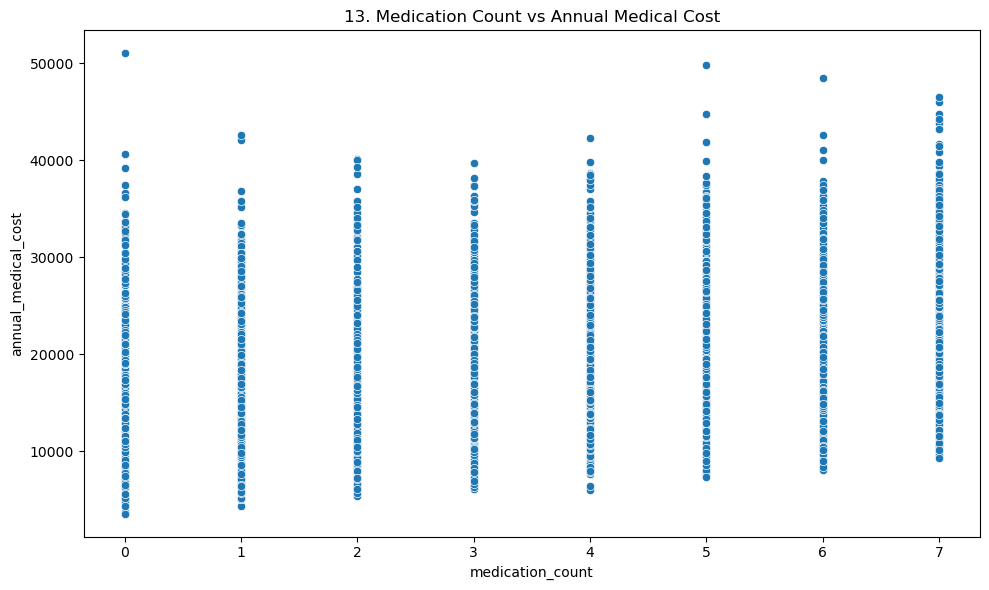

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='medication_count', y='annual_medical_cost', data=df)
plt.title(f'{plot_no}. Medication Count vs Annual Medical Cost')
show_fig()
plot_no += 1

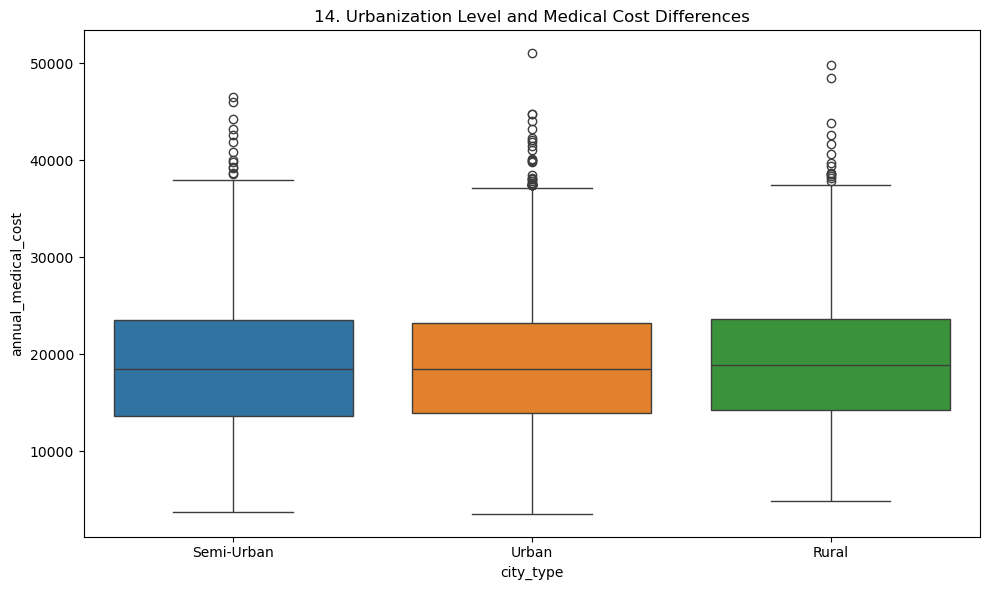

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='city_type', y='annual_medical_cost', hue='city_type', data=df)
plt.title(f'{plot_no}. Urbanization Level and Medical Cost Differences')
show_fig()
plot_no += 1

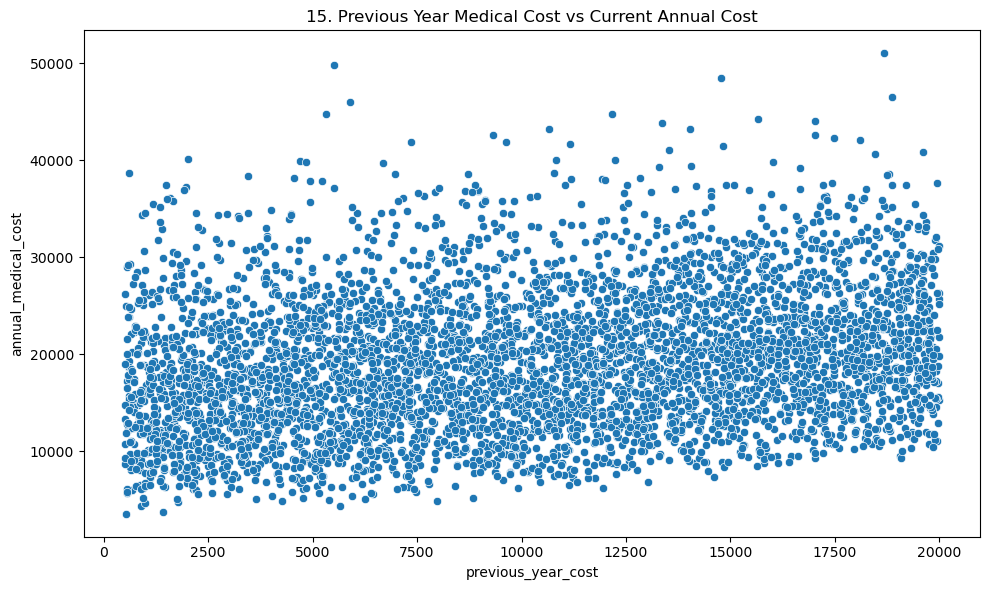

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='previous_year_cost', y='annual_medical_cost', data=df)
plt.title(f'{plot_no}. Previous Year Medical Cost vs Current Annual Cost')
show_fig()
plot_no += 1

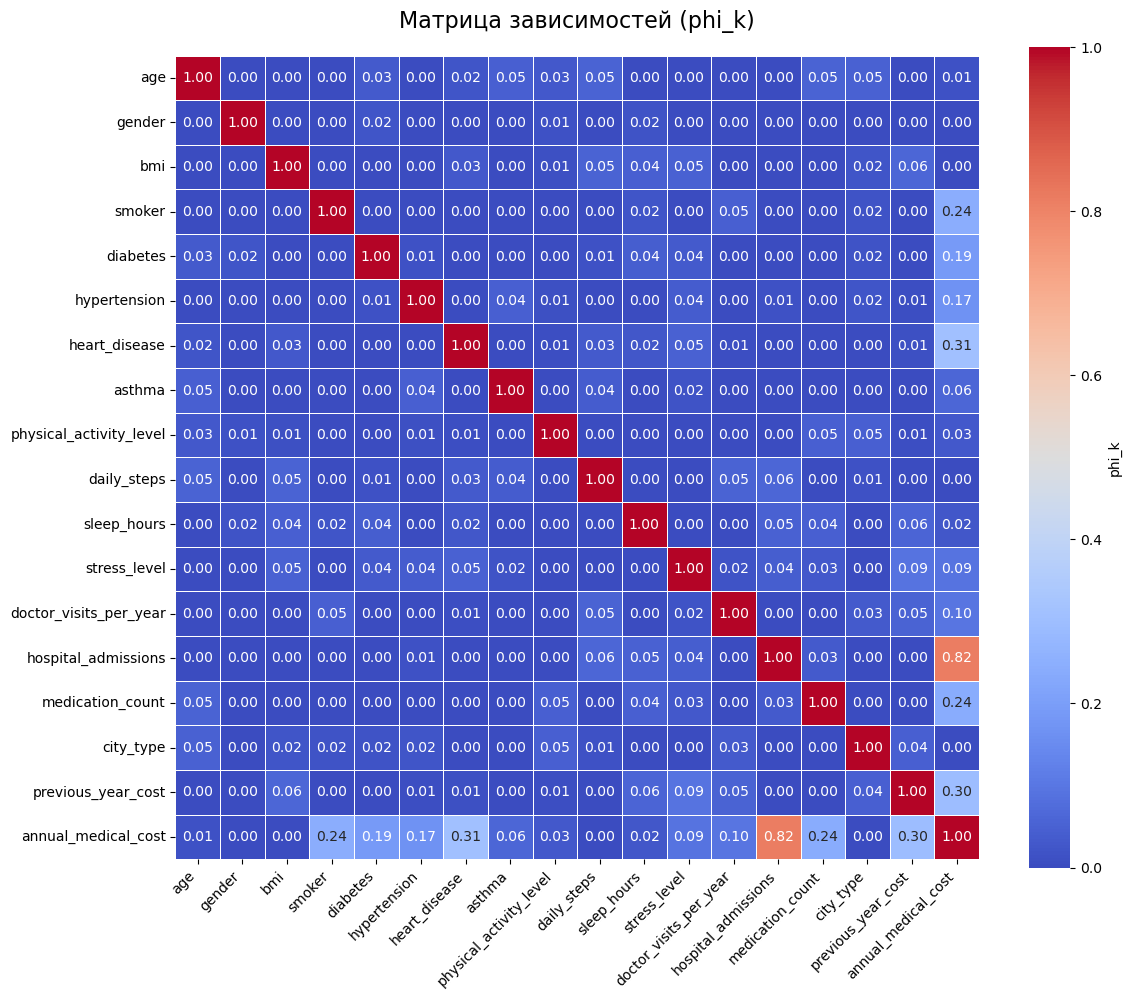

In [27]:
phik_matrix = df.phik_matrix(interval_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'previous_year_cost', 'annual_medical_cost'])

plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_matrix,
    annot=True,         
    fmt=".2f",         
    cmap="coolwarm",    
    vmin=0,
    vmax=1,          
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "phi_k"}
)

plt.title("Матрица зависимостей (phi_k)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Обучение ML-модели

In [28]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['smoker'] = df['smoker'].map({'Yes': 1, 'No': 0})

In [29]:
X = df.drop('annual_medical_cost', axis=1)
y = df['annual_medical_cost']

In [30]:
X.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,city_type,previous_year_cost
0,69,1,29.4,0,1,0,0,0,Medium,14825,4.4,8,1,0,4,Semi-Urban,10885
1,32,0,22.9,0,1,0,0,0,Medium,3620,6.0,7,4,3,0,Semi-Urban,18722
2,89,1,25.7,0,0,0,0,0,High,10578,4.5,7,2,0,3,Urban,4196
3,78,1,31.9,1,0,1,0,0,Low,6226,8.6,9,6,1,7,Urban,11128
4,38,1,27.7,0,0,0,0,0,High,6253,5.7,3,6,0,6,Urban,15110


In [31]:
num_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours',
            'doctor_visits_per_year', 'hospital_admissions', 'medication_count',
           'previous_year_cost']

cat_cols = ['physical_activity_level', 'city_type']

bin_cols = ['gender', 'smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma']

In [32]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])

bin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('bin', bin_pipeline, bin_cols)
])

In [33]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

In [34]:
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [37]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}")

MAE  : 976.19
RMSE : 1288.30
R²   : 0.9655
MAPE : 0.06


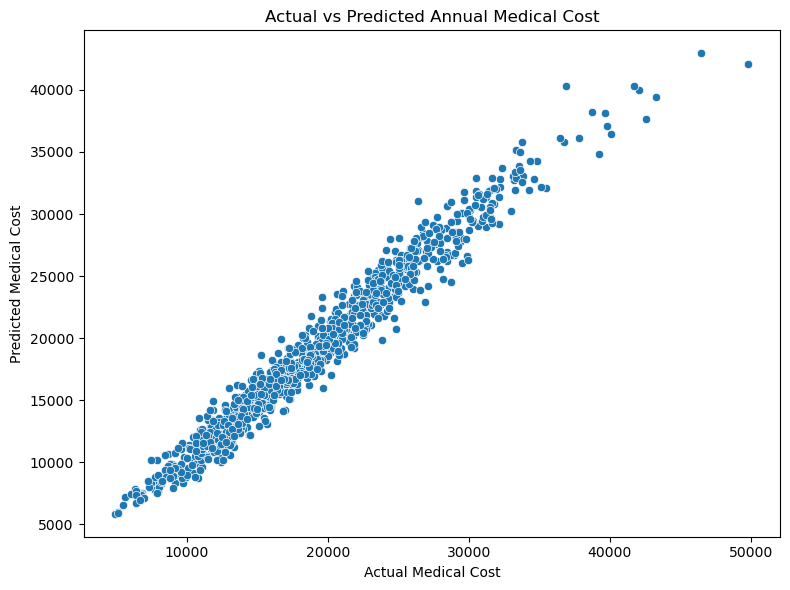

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Medical Cost")
plt.ylabel("Predicted Medical Cost")
plt.title("Actual vs Predicted Annual Medical Cost")
plt.tight_layout()
plt.show()

In [39]:
joblib.dump(pipeline, "rf_pipeline.joblib")

['rf_pipeline.joblib']

## Объяснение влияния факторов на прогноз с помощью SHAP

In [40]:
def aggregate_shap_values(explanation):
    # Достаём из SHAP-объекта названия признаков, SHAP-значения и значения признаков
    feature_names = explanation.feature_names
    shap_values = explanation.values
    data = explanation.data

    # Словарь для агрегации SHAP-значений по исходным признакам
    aggregated = {}

    for i, name in enumerate(feature_names):
        # Убираем префикс трансформера из названия признака,
        # например: "cat__city_type_Urban" -> "city_type_Urban"
        clean_name = name.split("__", 1)[-1]

        # Для one-hot encoded признаков восстанавливаем название исходной переменной.
        # Например: "city_type_Urban" -> "city_type".
        # Разделяем по последнему "_", чтобы корректно обрабатывать признаки,
        # в названии которых уже могут быть подчёркивания.
        if "_" in clean_name and not clean_name.startswith("num"):
            base_feature = clean_name.rsplit("_", 1)[0]
        else:
            base_feature = clean_name

        # Если исходный признак ещё не встречался, создаём для него запись
        if base_feature not in aggregated:
            aggregated[base_feature] = {
                "shap_value": 0.0,
                "feature_value": None
            }

        # Суммируем SHAP-значения всех dummy-признаков,
        # относящихся к одной исходной переменной
        aggregated[base_feature]["shap_value"] += shap_values[i]

        # Сохраняем одно репрезентативное значение признака.
        # Для числовых признаков это будет исходное значение,
        # для one-hot encoded признаков — значение одной из dummy-переменных.
        if aggregated[base_feature]["feature_value"] is None:
            aggregated[base_feature]["feature_value"] = data[i]

    # Переводим агрегированные значения в DataFrame
    df = pd.DataFrame([
        {"feature": k, "value": v["feature_value"], "shap_value": v["shap_value"]}
        for k, v in aggregated.items()
    ])

    # Сортируем признаки по абсолютному влиянию на предсказание
    df = df.reindex(df.shap_value.abs().sort_values(ascending=False).index)

    return df

In [41]:
pipeline = joblib.load("rf_pipeline.joblib")

In [42]:
preprocessor = pipeline.named_steps['preprocess']
model = pipeline.named_steps['model']
explainer = shap.TreeExplainer(model)

### Проверим на тестовом примере

In [43]:
sample = pd.DataFrame([X_test.iloc[0].to_dict()])
sample_transformed = preprocessor.transform(sample)
shap_values = explainer(sample_transformed)
feature_names = preprocessor.get_feature_names_out()

In [44]:
feature_names

array(['num__age', 'num__bmi', 'num__daily_steps', 'num__sleep_hours',
       'num__doctor_visits_per_year', 'num__hospital_admissions',
       'num__medication_count', 'num__previous_year_cost',
       'cat__physical_activity_level_Low',
       'cat__physical_activity_level_Medium', 'cat__city_type_Semi-Urban',
       'cat__city_type_Urban', 'bin__gender', 'bin__smoker',
       'bin__diabetes', 'bin__hypertension', 'bin__heart_disease',
       'bin__asthma'], dtype=object)

In [45]:
explanation = shap.Explanation(
    values=shap_values.values[0],
    base_values=shap_values.base_values[0],
    data=sample_transformed[0],
    feature_names=feature_names
)

agg_df = aggregate_shap_values(explanation)

In [46]:
agg_df

,feature,value,shap_value
5,hospital,0.0,-6114.074110
6,medication,0.0,-2235.053907
7,previous_year,7029.0,-1085.791011
14,heart,0.0,-818.544851
11,smoker,0.0,-632.030121
13,hypertension,0.0,-510.288826
12,diabetes,0.0,-412.536340
4,doctor_visits_per,5.0,318.003410
0,age,36.0,-146.288711
15,asthma,0.0,-31.234401


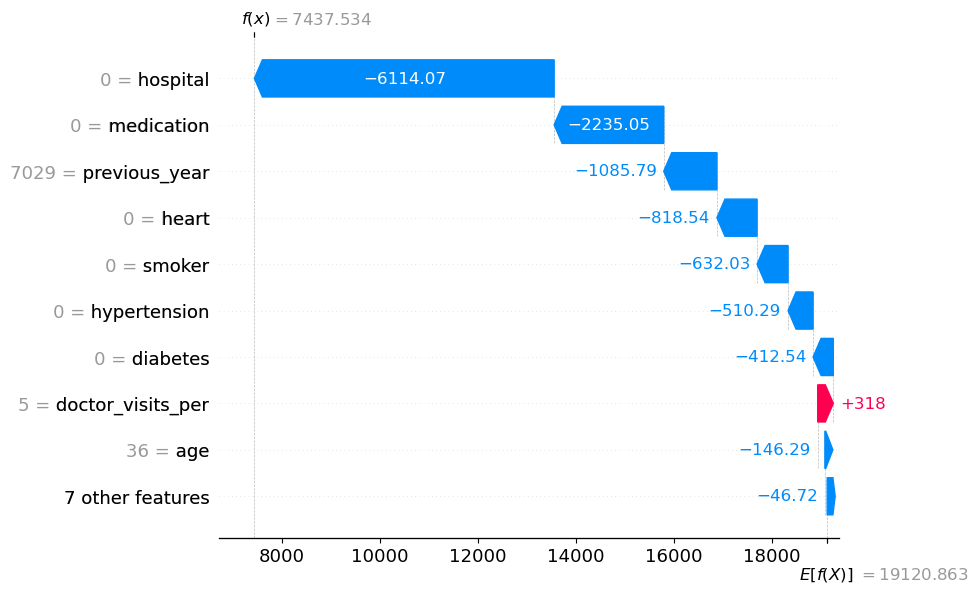

In [47]:
agg_explanation = shap.Explanation(
    values=agg_df["shap_value"].values,
    base_values=explanation.base_values,
    data=agg_df["value"].values,
    feature_names=agg_df["feature"].values
)

shap.plots.waterfall(agg_explanation)